In [15]:
# Setup: Add src directory to path for custom module imports
import sys
import os

sys.path.append(
    os.path.abspath("../src")

)
print("✓ Python path configured")

✓ Python path configured


In [17]:
# Load NuScenes dataset
from data_loader import load_nuscenes


nusc = load_nuscenes()
print(f"✓ NuScenes dataset loaded with {len(nusc.scene)} scenes")

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.130 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
✓ NuScenes dataset loaded with 10 scenes


In [18]:
# Extract first scene and its first sample
scene = nusc.scene[0]

sample = nusc.get(
    "sample",
    scene["first_sample_token"]

)
print(f"✓ Sample token: {sample['token'][:8]}...")
print(f"✓ Scene '{scene['name']}' loaded")

✓ Sample token: ca9a282c...
✓ Scene 'scene-0061' loaded


In [20]:
# Extract camera and LiDAR data tokens from sample
cam_token = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]

cam_data = nusc.get(
    "sample_data",
    cam_token
)

lidar_data = nusc.get(
    "sample_data",
    lidar_token
)

print(f"✓ Camera data filename: {cam_data['filename']}")

print(f"✓ LiDAR data filename: {lidar_data['filename']}")

✓ Camera data filename: samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
✓ LiDAR data filename: samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [21]:
# Get calibration parameters for both sensors
from geometry.calibration import (
    get_camera_calibration,
    get_lidar_calibration
)

cam_calib = get_camera_calibration(
    nusc,
    cam_data
)

lidar_calib = get_lidar_calibration(
    nusc,
    lidar_data

)
print(f"✓ LiDAR calibration obtained: {list(lidar_calib.keys())}")
print(f"✓ Camera calibration obtained: {list(cam_calib.keys())}")

✓ LiDAR calibration obtained: ['token', 'sensor_token', 'translation', 'rotation', 'camera_intrinsic']
✓ Camera calibration obtained: ['token', 'sensor_token', 'translation', 'rotation', 'camera_intrinsic']


In [22]:
# Construct full path to LiDAR point cloud file
import os

lidar_path = os.path.join(
    nusc.dataroot,
    lidar_data["filename"]

)
print(f"  File exists: {os.path.exists(lidar_path)}")
print(f"✓ LiDAR file path: {lidar_path}")

  File exists: True
✓ LiDAR file path: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin


In [24]:
# Load LiDAR point cloud from file
from nuscenes.utils.data_classes import (
    LidarPointCloud
)

pc = LidarPointCloud.from_file(
    lidar_path

)
print(f"  Points count: {pc.points.shape[1]}")

print(f"✓ Point cloud loaded")
print(f"  Shape: {pc.points.shape}")

  Points count: 34688
✓ Point cloud loaded
  Shape: (4, 34688)


In [25]:
# Convert points to homogeneous coordinates (x, y, z, 1)
import numpy as np

points = pc.points[:3, :]  # Extract x, y, z coordinates

ones = np.ones(
    (1, points.shape[1])
)

points_hom = np.vstack(
    [points, ones]

)
print(f"  Sample points:\n{points_hom[:, :3]}")

print(f"✓ Homogeneous coordinates created")
print(f"  Homogeneous shape: {points_hom.shape}")
print(f"  Original shape: {points.shape}")

  Sample points:
[[-3.12437344 -3.2906363  -3.47041011]
 [-0.43415368 -0.43220678 -0.43068862]
 [-1.86719203 -1.86318922 -1.85956275]
 [ 1.          1.          1.        ]]
✓ Homogeneous coordinates created
  Homogeneous shape: (4, 34688)
  Original shape: (3, 34688)


In [26]:
# Transform points from LiDAR frame to camera frame
from geometry.coordinate_frames import (
    lidar_to_camera
)

points_cam = lidar_to_camera(
    points_hom,
    lidar_calib,
    cam_calib

)
print(f"  Sample transformed points:\n{points_cam[:, :3]}")

print(f"✓ LiDAR to camera coordinate transformation applied")
print(f"  Output shape: {points_cam.shape}")

  Sample transformed points:
[[-3.12657048 -3.29279453 -3.47253317]
 [ 1.51275693  1.50767295  1.5028664 ]
 [-1.21645824 -1.21383657 -1.21160173]
 [ 1.          1.          1.        ]]
✓ LiDAR to camera coordinate transformation applied
  Output shape: (4, 34688)


In [28]:
# Project 3D camera points to 2D image coordinates
from geometry.projection import (
    project_points_to_image
)

u, v = project_points_to_image(
    points_cam,
    cam_calib["camera_intrinsic"]

)

print(f"  Sample projections: u={u[:3]}, v={v[:3]}")

print(f"✓ Points projected to image plane")
print(f"  V (y) range: [{v.min():.1f}, {v.max():.1f}]")
print(f"  U (x) range: [{u.min():.1f}, {u.max():.1f}]")

  Sample projections: u=[-8033462.28272122 -4129654.23282213 -1299383.00069954], v=[-1746428.32422004   -18153.87446381   -35714.96344   ]
✓ Points projected to image plane
  V (y) range: [-1746428.3, 2431411.7]
  U (x) range: [-8971753.0, 9641196.6]


In [30]:
# Load and convert camera image
import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(
    nusc.dataroot,
    cam_data["filename"]
)

image = cv2.imread(img_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB

)
print(f"  Data type: {image.dtype}")
print(f"✓ Camera image loaded")
print(f"  Image shape: {image.shape}")

  Data type: uint8
✓ Camera image loaded
  Image shape: (900, 1600, 3)


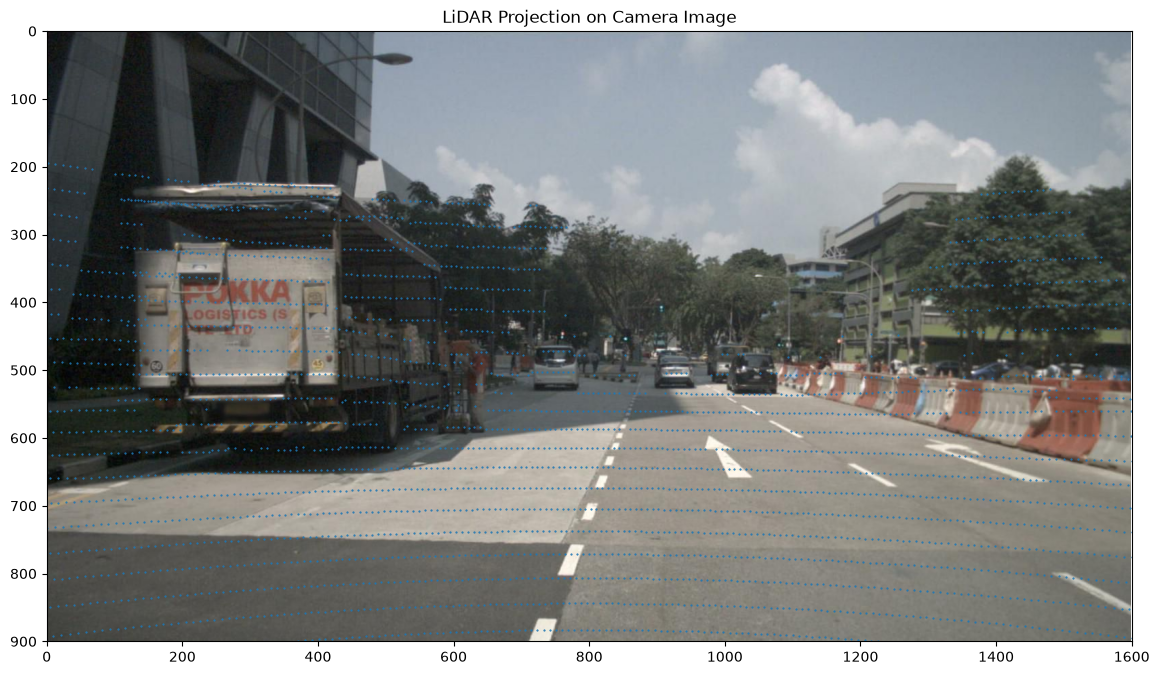

✓ Visualization complete - 11761 points projected


In [31]:
# Visualize: Project LiDAR points onto camera image
# This shows the spatial relationship between LiDAR and camera data
plt.figure(figsize=(14, 8))

plt.imshow(image)

plt.scatter(
    u,
    v,
    s=0.3
)

plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)

plt.title(
    "LiDAR Projection on Camera Image"
)

plt.show()
print(f"✓ Visualization complete - {len(u)} points projected")

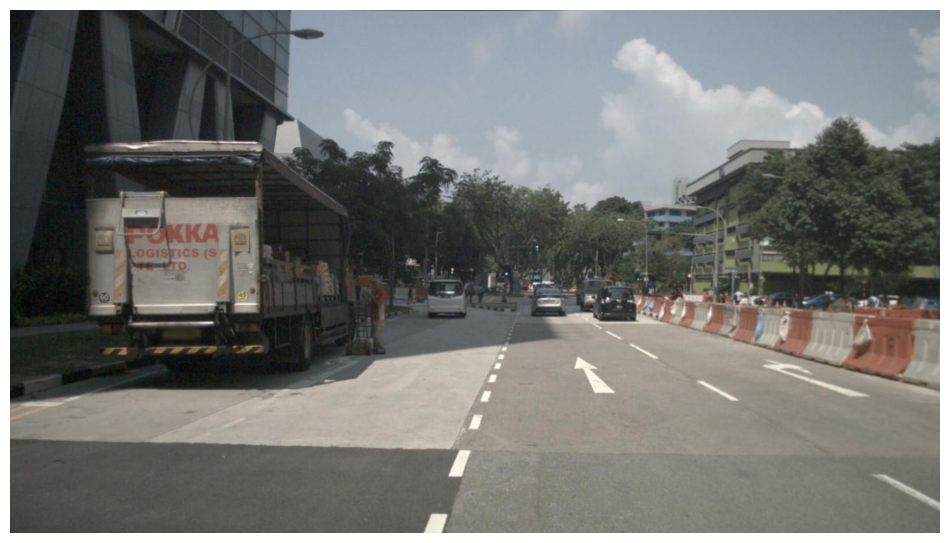

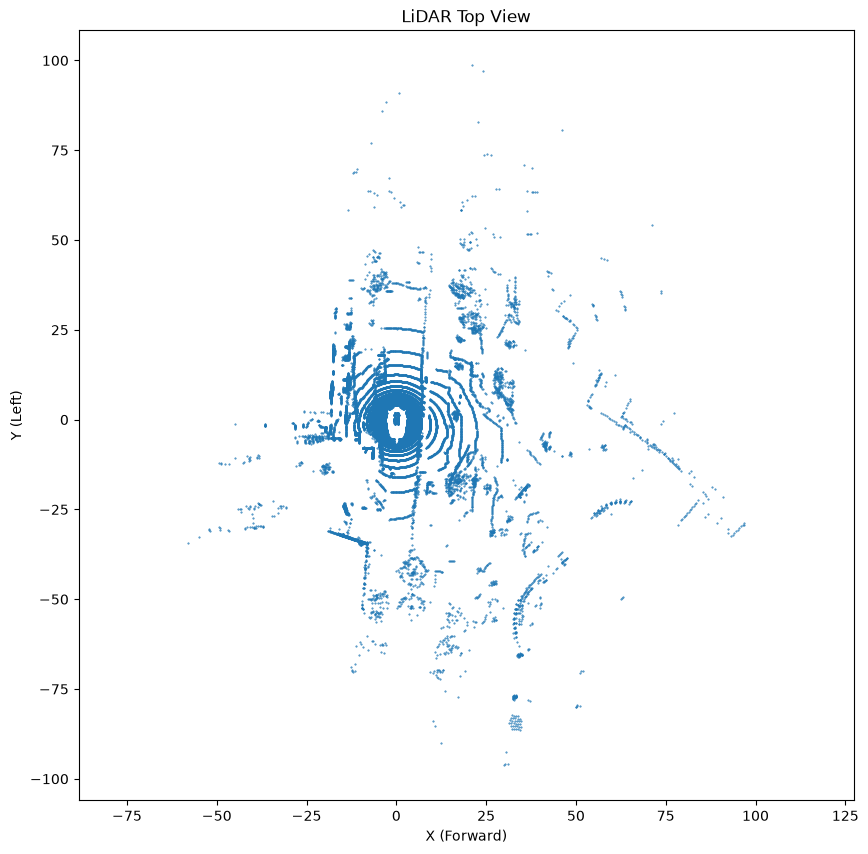

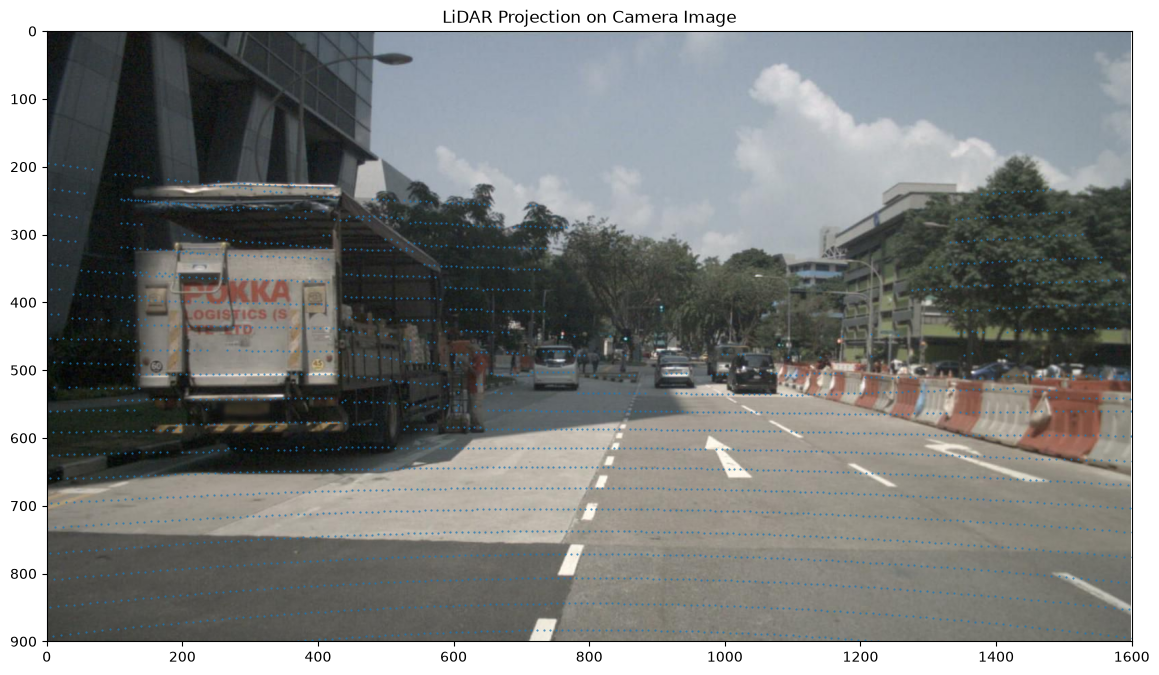

In [33]:
from visualization.image_view import (
    display_image,
    save_image
)

from visualization.lidar_view import (
    plot_lidar_top_view
)

from visualization.projection_view import (
    visualize_projection
)

display_image(image)

save_image(
    image,
    "../outputs/images/camera_image.png"
)

plot_lidar_top_view(
    pc.points,
    "../outputs/images/raw_lidar_top_view.png"
)

visualize_projection(
    image,
    u,
    v,
    "../outputs/images/projected_lidar_overlay.png"
)